In [25]:
import xclone
import anndata as an
import pandas as pd
import numpy as np
import scipy
import anndata
import xclone
import scanpy as sc
import os
print("scipy", scipy.__version__)

scipy 1.13.1


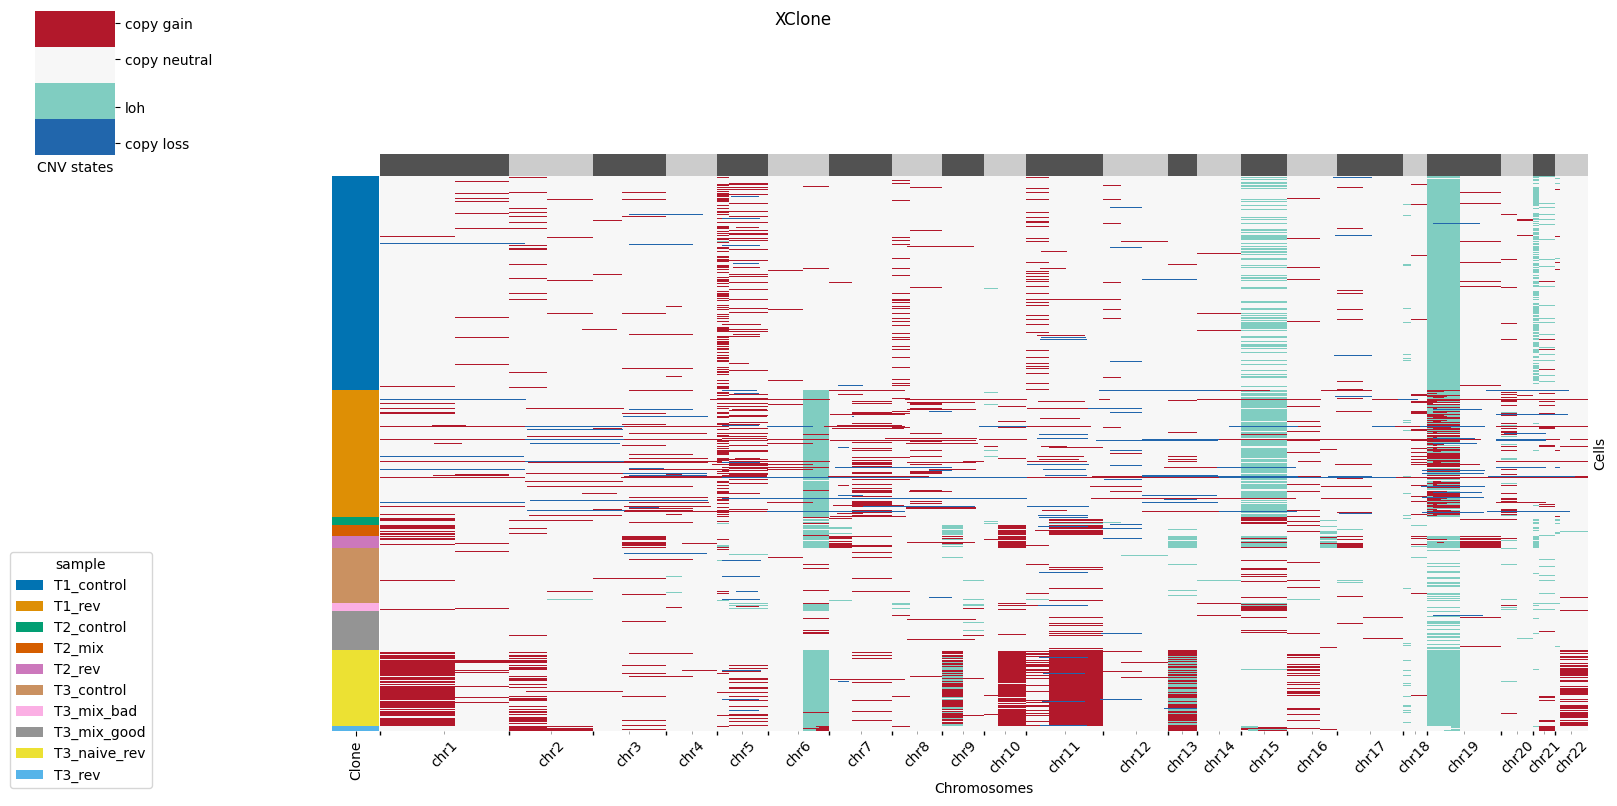

In [5]:
# Visualize combined CNA with custom settings
colorbar_ticks = [0.25,1,2,2.75]
colorbar_label = ["copy loss","loh", "copy neutral", "copy gain"]
xclone.pl.Combine_CNV_visualization(combined_Xdata, Xlayer = "plot_prob_merge1", 
                            cell_anno_key = 'sample', 
                            color_map_name = "combine_cmap", 
                            states_num = 4, 
                            colorbar_ticks = colorbar_ticks,
                            colorbar_label = colorbar_label,
                            #title = fig_title,
                            save_file = True, 
                            out_file = out_dir + "")

In [23]:
def make_xclone_ploidy_df(celltype: str):
    """
    Build a cell × chr ploidy dataframe from XClone combine output and
    save it in an scploid-like long format.

    celltype: name of the subfolder under 5_xclone_combine (e.g. 'EPI').
    """

    base_dir = "/ceph.groups/mshahbazi.grp/rsakata/FromSanger/Aneuploid_screen_v2/processed_data/7_xclone/5_xclone_combine"
    in_path = os.path.join(base_dir, celltype, "data", "combined_final.h5ad")
    out_base = os.path.join(base_dir, celltype)

    print(f"Loading: {in_path}")
    adata = sc.read_h5ad(in_path)

    # --- sanity checks ---
    assert "prob1_merge" in adata.layers, "prob1_merge not found in .layers"
    assert "chr" in adata.var.columns, "No 'chr' column in .var"

    prob = adata.layers["prob1_merge"]        # (n_cells, n_genes, 4)
    n_cells, n_genes, n_states = prob.shape
    print("prob1_merge shape:", prob.shape)

    # XClone combine states (indices 0..3).
    # NOTE: adjust labels if you want to treat LOH separately;
    # this line currently treats both state 1 and 2 as "normal".
    state_labels = np.array(["monosomy", "normal", "normal", "trisomy"])

    # --- chromosome info ---
    chroms = adata.var["chr"].astype(str).to_numpy()   # one per gene
    unique_chroms = pd.unique(chroms)

    # --- aggregate per chromosome using mean prob across genes ---
    cell_chr_states = pd.DataFrame(index=adata.obs_names,
                                   columns=unique_chroms,
                                   dtype=object)

    for chr_name in unique_chroms:
        gene_idx = np.where(chroms == chr_name)[0]
        if gene_idx.size == 0:
            continue

        # prob for this chromosome: (cells × genes_chr × 4)
        prob_chr = prob[:, gene_idx, :]

        # average over genes → (cells × 4)
        mean_prob_chr = prob_chr.mean(axis=1)

        # hard call per cell: argmax over 4 states
        state_idx_chr = mean_prob_chr.argmax(axis=1)           # (cells,)
        cell_chr_states[chr_name] = state_labels[state_idx_chr]

    # --- convert to scploid-like long format (cell, chr, ploidy) ---
    cell_chr_states_wide = cell_chr_states.copy()
    cell_chr_states_wide.insert(0, "cell", cell_chr_states_wide.index)

    cell_chr_states_long = cell_chr_states_wide.melt(
        id_vars="cell",
        var_name="chr",
        value_name="ploidy"
    )

    # optional: strip "chr" prefix if present
    cell_chr_states_long["chr"] = (
        cell_chr_states_long["chr"].astype(str).str.replace("^chr", "", regex=True)
    )

    # --- save to disk ---
    os.makedirs(out_base, exist_ok=True)
    out_path = os.path.join(out_base, f"ploidydf_xclone_{celltype}.csv")
    cell_chr_states_long.to_csv(out_path, index=False)

    print(f"Done. Saved: {out_path}")
    print("Shape:", cell_chr_states_long.shape)



In [30]:
celltype = "EPI"
make_xclone_ploidy_df(celltype)

Loading: /ceph.groups/mshahbazi.grp/rsakata/FromSanger/Aneuploid_screen_v2/processed_data/7_xclone/5_xclone_combine/EPI/data/combined_final.h5ad
prob1_merge shape: (8151, 8383, 4)
Done. Saved: /ceph.groups/mshahbazi.grp/rsakata/FromSanger/Aneuploid_screen_v2/processed_data/7_xclone/5_xclone_combine/EPI/ploidydf_xclone_EPI.csv
Shape: (179322, 3)


In [26]:
celltype = "TE"
make_xclone_ploidy_df(celltype)

Loading: /ceph.groups/mshahbazi.grp/rsakata/FromSanger/Aneuploid_screen_v2/processed_data/7_xclone/5_xclone_combine/TE/data/combined_final.h5ad
prob1_merge shape: (2674, 8383, 4)
Done. Saved: /ceph.groups/mshahbazi.grp/rsakata/FromSanger/Aneuploid_screen_v2/processed_data/7_xclone/5_xclone_combine/TE/ploidydf_xclone_TE.csv
Shape: (58828, 3)


In [27]:
celltype = "unspecified"
make_xclone_ploidy_df(celltype)

Loading: /ceph.groups/mshahbazi.grp/rsakata/FromSanger/Aneuploid_screen_v2/processed_data/7_xclone/5_xclone_combine/unspecified/data/combined_final.h5ad
prob1_merge shape: (27830, 8383, 4)
Done. Saved: /ceph.groups/mshahbazi.grp/rsakata/FromSanger/Aneuploid_screen_v2/processed_data/7_xclone/5_xclone_combine/unspecified/ploidydf_xclone_unspecified.csv
Shape: (612260, 3)


In [32]:
files = [
    "/ceph.groups/mshahbazi.grp/rsakata/FromSanger/Aneuploid_screen_v2/processed_data/7_xclone/5_xclone_combine/unspecified/ploidydf_xclone_unspecified.csv",
    "/ceph.groups/mshahbazi.grp/rsakata/FromSanger/Aneuploid_screen_v2/processed_data/7_xclone/5_xclone_combine/EPI/ploidydf_xclone_EPI.csv",
    "/ceph.groups/mshahbazi.grp/rsakata/FromSanger/Aneuploid_screen_v2/processed_data/7_xclone/5_xclone_combine/TE/ploidydf_xclone_TE.csv",
]

dfs = [pd.read_csv(f) for f in files]
ploidy_all = pd.concat(dfs, ignore_index=True)

out_path = "/ceph.groups/mshahbazi.grp/rsakata/FromSanger/Aneuploid_screen_v2/processed_data/7_xclone/6_final_plots"
ploidy_all.to_csv(out_path + "/ploidydf_xclone.csv", index=False)
